Import the libraries.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

### I. Frequent value Imputation.

Read the data.

In [2]:
df = pd.read_csv('Datasets/housing.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
797,NaN,TA,110000
1107,Gd,TA,274725
1119,NaN,TA,133700
748,TA,TA,260400
1399,Gd,Fa,137450


Find the percentage null values.

In [3]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Plots.

<Axes: xlabel='GarageQual'>

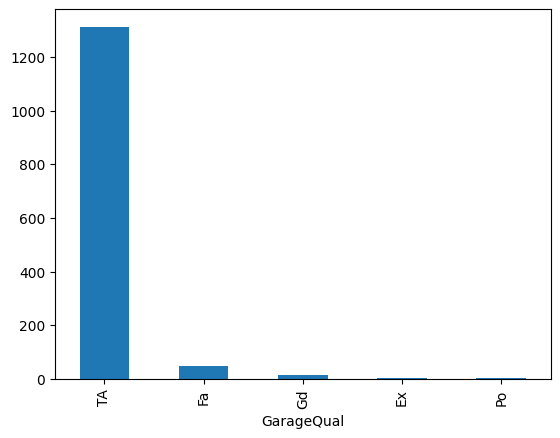

In [4]:
df['GarageQual'].value_counts().plot(kind='bar')

In [5]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

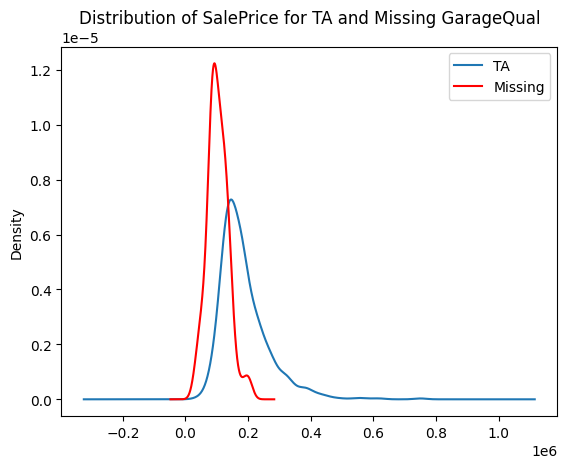

In [6]:
fig = plt.figure()
ax = plt.subplot(111)
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde',ax=ax, label='TA')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red', label='Missing')
plt.legend()
plt.title('Distribution of SalePrice for TA and Missing GarageQual')
plt.show()

<Axes: xlabel='GarageQual'>

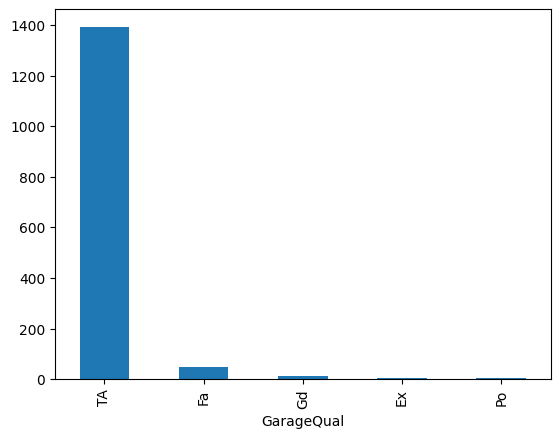

In [7]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']
df.fillna({'GarageQual': 'TA'}, inplace=True)
df['GarageQual'].value_counts().plot(kind='bar')

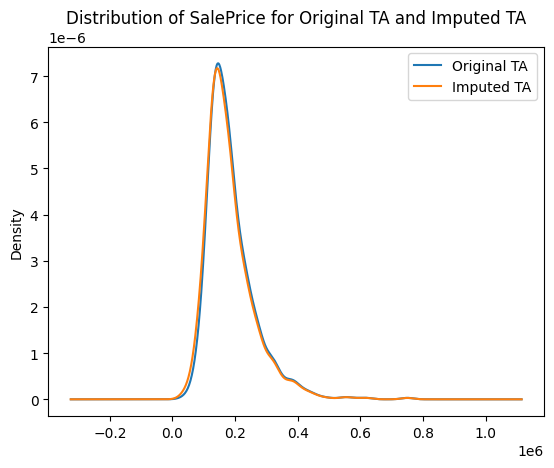

In [8]:
fig = plt.figure()
plt.subplot(111)

temp.plot(kind='kde', label='Original TA')
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', label='Imputed TA')
plt.legend()
plt.title('Distribution of SalePrice for Original TA and Imputed TA')
plt.show()


In [9]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

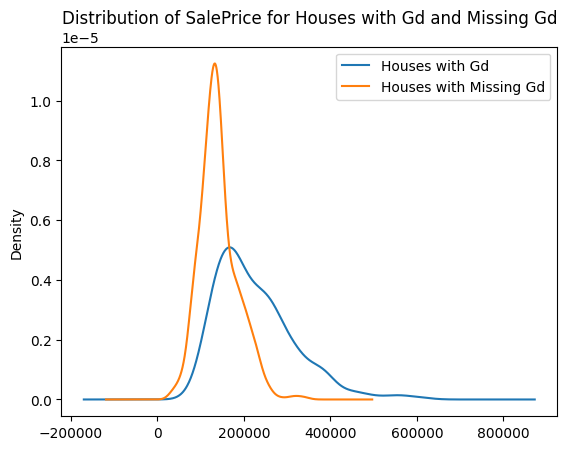

In [10]:
fig = plt.figure()
plt.subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', label='Houses with Gd')
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', label='Houses with Missing Gd')
plt.legend()
plt.title('Distribution of SalePrice for Houses with Gd and Missing Gd')
plt.show()

<Axes: xlabel='FireplaceQu'>

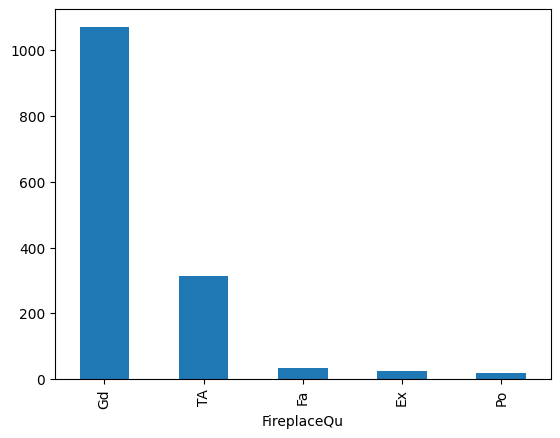

In [11]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']
df.fillna({'FireplaceQu': 'Gd'}, inplace=True)
df['FireplaceQu'].value_counts().plot(kind='bar')

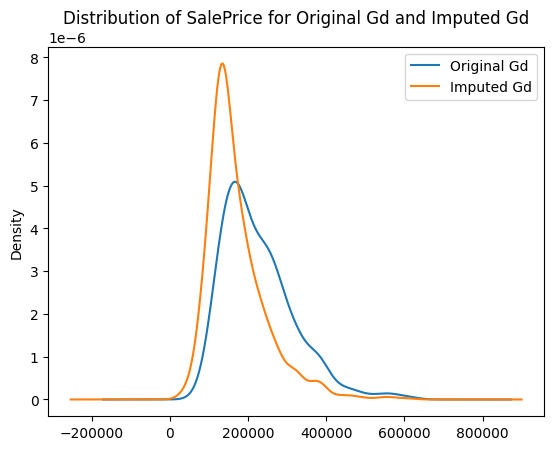

In [12]:
fig = plt.figure()
plt.subplot(111)

temp.plot(kind='kde', label='Original Gd')
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', label='Imputed Gd')
plt.legend()
plt.title('Distribution of SalePrice for Original Gd and Imputed Gd')
plt.show()

Split the data into train and test.

In [13]:
x = df.drop('SalePrice', axis=1)
y = df['SalePrice']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

Imputer with most frequent technique and fit and transform the train data and transforom the test data.

In [14]:
imputer = SimpleImputer(strategy='most_frequent')
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

### II. Missing category Imputation.

Read the data.

In [15]:
df2 = pd.read_csv('Datasets/housing.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df2.sample(5)

,FireplaceQu,GarageQual,SalePrice
1170,Po,TA,171000
220,NaN,TA,204900
884,NaN,TA,100000
450,NaN,Fa,110000
142,NaN,TA,166000


Plots.

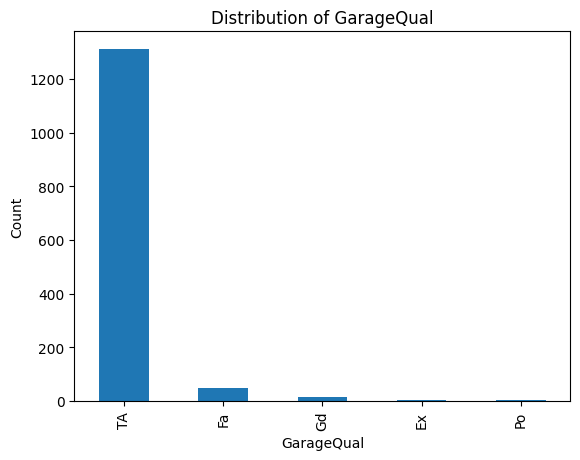

In [16]:
df2['GarageQual'].value_counts().plot(kind='bar')
plt.xlabel('GarageQual')
plt.ylabel('Count')
plt.title('Distribution of GarageQual')
plt.show()

In [17]:
df2['GarageQual'] = df2['GarageQual'].fillna('Missing')

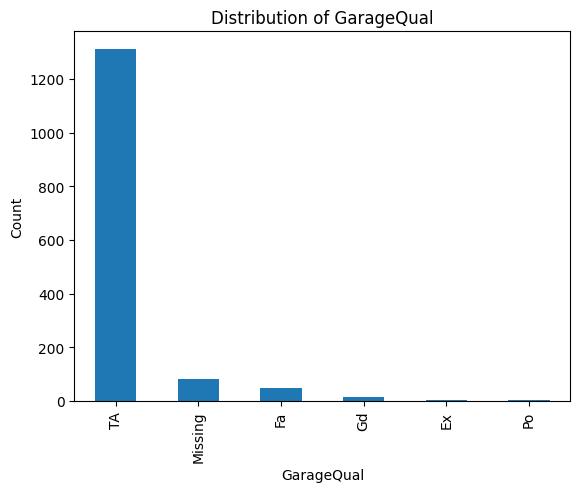

In [18]:
df2['GarageQual'].value_counts().plot(kind='bar')
plt.xlabel('GarageQual')
plt.ylabel('Count')
plt.title('Distribution of GarageQual')
plt.show()

Split the data into train and test and impute with constant technique.

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
imputer = SimpleImputer(strategy='constant', fill_value='Missing')
x_train_imputed = imputer.fit_transform(x_train)
x_test_imputed = imputer.transform(x_test)
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)